### **Stocaastic Gradient decent ,Batch Gradient decent & mini batch gradient decent : -**

### **Batch Gradient Decent :-**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [198]:
df = pd.read_csv('/Users/yuvrajbhatkariya/data/VScode.C++/Python/DeepLearning/dataset/homeprices_banglore.csv')

In [199]:
df.sample(10)

,area,bedrooms,price
1,2600,4,120.0
18,2770,3,102.0
3,1521,3,75.0
19,800,1,32.0
7,3300,4,155.0
12,1000,2,38.0
11,2785,4,140.0
6,2732,4,135.0
17,1540,3,60.0
8,1310,3,50.0


In [200]:
from sklearn import preprocessing 
sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

scaled_x = sx.fit_transform(df.drop('price',axis = 'columns'))
scaled_y = sy.fit_transform(df['price'].values.reshape(df.shape[0],1))

scaled_x

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [201]:
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [202]:
df.shape

(20, 3)

In [203]:
scaled_y.shape

(20, 1)

In [204]:
scaled_y.reshape(20,)

array([0.05237037, 0.65185185, 0.22222222, 0.31851852, 0.14074074,
       0.04444444, 0.76296296, 0.91111111, 0.13333333, 1.        ,
       0.37037037, 0.8       , 0.04444444, 0.05925926, 0.51111111,
       0.07407407, 0.11851852, 0.20740741, 0.51851852, 0.        ])

In [205]:
scaled_y.shape

(20, 1)

In [ ]:
def batch_gradient_descent(x,y_true,epochs,learning_rate = 0.001):

    no_of_feature = x.shape[1]
    w = np.ones(shape = (no_of_feature))
    b = 0
    total_sample = x.shape[0]

    cost_list = []
    epoch_list= []

    for i in range(epochs):
        y_predicted = np.dot(w, x.T) + b

        # gradient of weights 
        w_grad = -(2/total_sample)*(x.T.dot(y_true - y_predicted))
        # gradient of bias 
        b_grad = -(2/total_sample)*(np.sum(y_true - y_predicted))
        

        # new weights 
        w = w - learning_rate*w_grad
        b = b - learning_rate*b_grad


        # Mean Square Error 
        cost = np.mean(np.square(y_true - y_predicted))

        if i%10 == 0:
            cost_list.append(cost)
            epoch_list.append(i)

    return w,b,cost,cost_list,epoch_list
w ,b, cost, cost_list,epoch_list = batch_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0]),1000)

In [4]:
w = np.ones(shape = (2))
w

array([1., 1.])

In [207]:
b

np.float64(-0.3019915616710489)

In [208]:
cost

np.float64(0.015801537410375655)

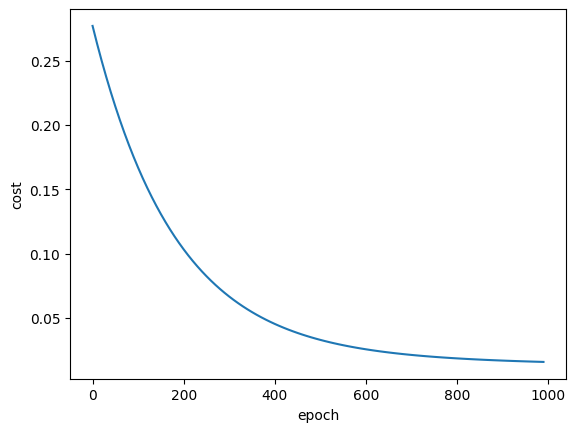

In [209]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

In [210]:
def predict(area,bedrooms,w,b):
    scaled_x = sx.transform([[area,bedrooms]])[0]

    scaled_price = w[0]*scaled_x[0] + w[1]*scaled_x[1] + b

    return sy.inverse_transform([[scaled_price]])[0][0]

predict(1100,2,w,b)

/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(29.305038223520835)

In [211]:
predict(2770,3,w,b)

/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(119.70742064976146)

### **2. Stochastic Gradient Descent :-**

In [212]:
import random
random.randint(0,8)

2

In [213]:
def stochastic_gradient_descent(x,y_true,epoch,learning_rate = 0.001):
    number_of_features = x.shape[1]
    
    w = np.ones(shape = (number_of_features))
    b = 0
    total_samples = x.shape[0]


    cost_list = []
    epoch_list = []

    for i in range(epoch):
        random_index = random.randint(0,total_samples-1)
        sample_x = x[random_index]
        sample_y = y_true[random_index]

        y_predicted = np.dot(w,sample_x) + b

        w_grad = -(2/total_samples)*(sample_x.T.dot(sample_y - y_predicted))
        b_grad = -(2/total_samples)*(sample_y - y_predicted)

        w = w - learning_rate*w_grad
        b = b - learning_rate*b_grad

        cost = np.square(sample_y - y_predicted)

        if i%10 == 0:
            cost_list.append(cost)
            epoch_list.append(i)

    
    return w,b,cost, cost_list, epoch_list

w_sgd,b_sgd,cost_sdg, cost_list,epoch_list = stochastic_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0],),1000)

In [214]:
w_sgd,b_sgd,cost_sdg

(array([0.97984577, 0.97493281]),
 np.float64(-0.04355391607182081),
 np.float64(0.1693127454741381))

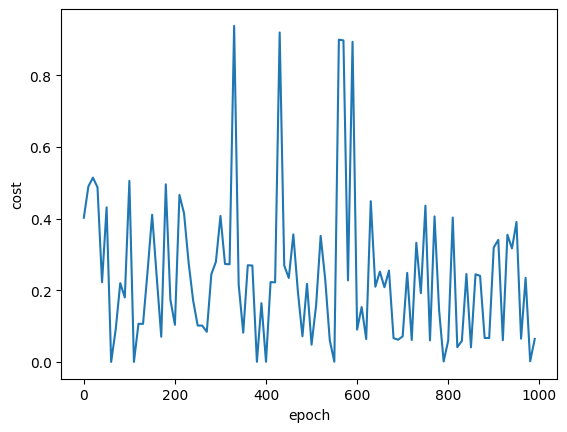

In [215]:

plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

In [216]:
def predict(area,bedrooms,w,b):
    scaled_x = sx.transform([[area,bedrooms]])[0]

    scaled_price = w[0]*scaled_x[0] + w[1]*scaled_x[1] + b

    return sy.inverse_transform([[scaled_price]])[0][0]

predict(1100,2,w_sgd,b_sgd)

/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(72.70825678446192)

In [217]:
predict(2770,3,w,b)


/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(119.70742064976146)

### **Mini Batch Gradient Descent: -**

In [218]:
def mini_batch_gradient_descent(df, batch_size, epoch, learning_rate=0.001):
    sx = preprocessing.MinMaxScaler()
    sy = preprocessing.MinMaxScaler()
    
    x = sx.fit_transform(df.drop('price', axis=1))
    y_true = sy.fit_transform(df[['price']]).flatten()  # Ensure y_true is a 1D array

    number_of_features = x.shape[1]
    w = np.ones(shape=(number_of_features))  
    b = 0  

    cost_list = []
    epoch_list = []

    total_samples = x.shape[0]

    for i in range(epoch):
        # Select a new random mini-batch at each epoch
        batch_indices = np.random.choice(total_samples, batch_size, replace=True)
        sample_x = x[batch_indices]
        sample_y = y_true[batch_indices]

        y_predicted = np.dot(sample_x, w) + b

        # Compute gradients (using mean for mini-batch updates)
        w_grad = -(2/batch_size) * np.dot(sample_x.T, (sample_y - y_predicted))
        b_grad = -(2/batch_size) * np.sum(sample_y - y_predicted)

        # Update weights and bias
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad

        # Compute mean squared error cost for the batch
        cost = np.mean(np.square(sample_y - y_predicted))

        if i % 10 == 0:
            cost_list.append(cost)
            epoch_list.append(i)

    return w, b, cost, cost_list, epoch_list

w_mbgd, b_mbgd, cost, cost_list, epoch_list = mini_batch_gradient_descent(df, batch_size=10, epoch=1000)

print("Final Weights:", w_mbgd)
print("Final Bias:", b_mbgd)
print("Final Cost:", cost)


Final Weights: [0.81751729 0.78699792]
Final Bias: -0.3034406584537784
Final Cost: 0.004914971396869159


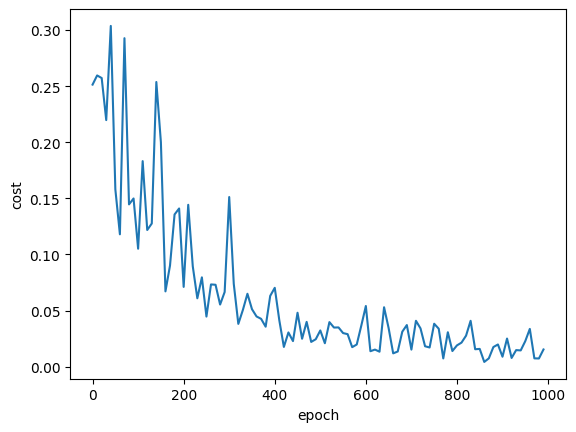

In [219]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

In [220]:
predict(2770,3,w_mbgd,b_mbgd)

/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(119.12984474003392)

In [221]:
predict(1100,2,w_mbgd,b_mbgd)

/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(29.013742827417854)